In [ ]:
#Student Name: Manikanta Reddy Mavuri
#Student ID: A00089768

In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [ ]:
# ================================
# 2. Download Data from Yahoo Finance
# ================================
# NIFTY 50 ticker
ticker = "^NSEI"

data = yf.download(ticker, start="2010-01-01", end="2024-01-01")

# Keep only 'Close' price
data = data[['Close']]


/tmp/ipykernel_3078/1094758249.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2010-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Data Cleaning

In [ ]:
data.isnull().sum()

,,0
Price,Ticker,
Close,^NSEI,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3434 entries, 2010-01-04 to 2023-12-29
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ^NSEI)  3434 non-null   float64
dtypes: float64(1)
memory usage: 53.7 KB


In the above data i have cleaned the data of past 14 years from 2010 to 2024 with 0 null values


In [ ]:
data.head()

Price,Close
Ticker,^NSEI
Date,
2010-01-04,5232.200195
2010-01-05,5277.899902
2010-01-06,5281.799805
2010-01-07,5263.100098
2010-01-08,5244.750000


For this LSTM Project i just took 2 values Date and close price and the dataset has been downloaded from the yahoo finance.

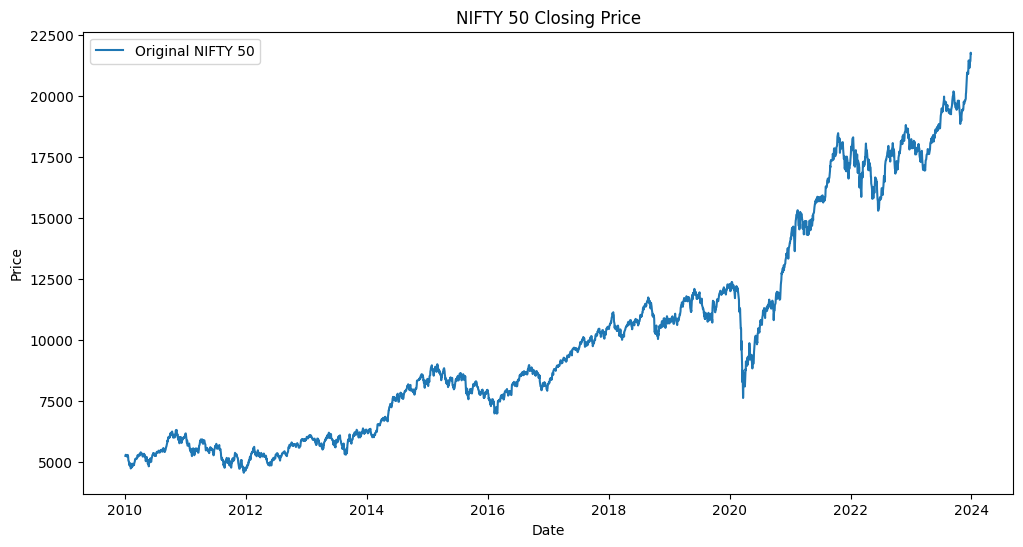

In [ ]:
# ================================
# 3. Visualize Original Data
# ================================
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label="Original NIFTY 50")
plt.title("NIFTY 50 Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


If we have a look over the chart it tells us that the price is consistantly incereassing moving higher every year. which is good sign for the indian market growth.

In [ ]:
# ================================
# 4. Data Preprocessing # make sure the taining and test are done as we talkd (Prediction Horizon, Prediction Gain)
# ================================
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Train-Test Split (80% train)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]


In [ ]:
# Function to create sequences
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

time_step = 60

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape for LSTM (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

model = Sequential()

# Add Input layer first
model.add(Input(shape=(time_step, 1)))

model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')


In [ ]:
# ================================
# 6. Train Model
# ================================
model.fit(X_train, y_train, batch_size=32, epochs=10)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0040
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.0590e-04
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.9559e-04
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1.8636e-04
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.8294e-04
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.6848e-04
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.3719e-04
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 1.3299e-04
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.3053e-04
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.2755e-04


In [ ]:
# ================================
# 7. Predictions
# ================================
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)


In [ ]:
# ================================
# 8. Prepare Data for Plotting
# ================================
train_plot = np.empty_like(scaled_data)
train_plot[:] = np.nan
train_plot[time_step:len(train_predict)+time_step] = train_predict

test_plot = np.empty_like(scaled_data)
test_plot[:] = np.nan
test_plot[len(train_predict)+(time_step*2):len(scaled_data)] = test_predict

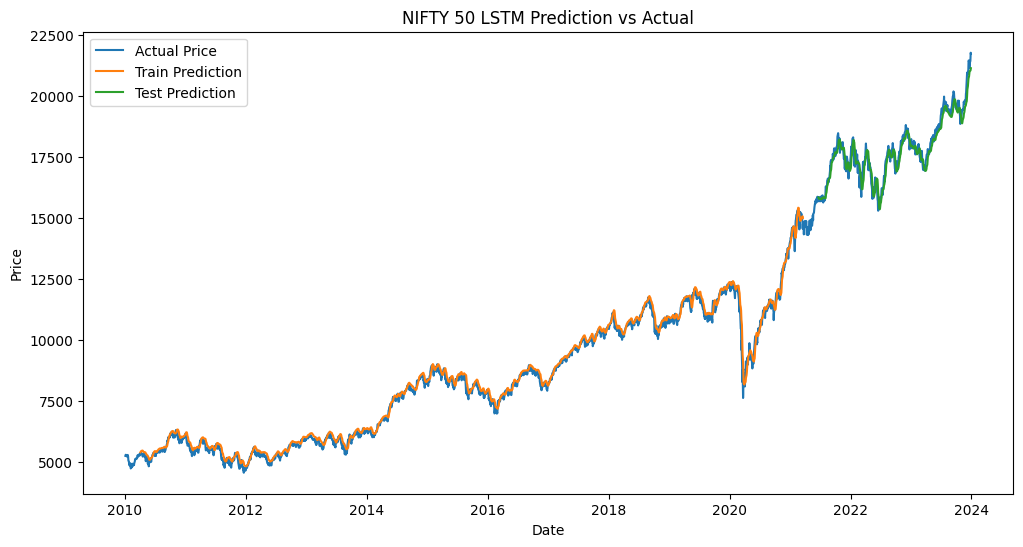

In [ ]:
# ================================
# 9. Visualization (Same X-Axis Dates)
# ================================
plt.figure(figsize=(12,6))

# Original Data
plt.plot(data.index, scaler.inverse_transform(scaled_data), label='Actual Price')

# Train Predictions
plt.plot(data.index, train_plot, label='Train Prediction')

# Test Predictions
plt.plot(data.index, test_plot, label='Test Prediction')

plt.title("NIFTY 50 LSTM Prediction vs Actual")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

The above predicted vs actual chart shows the 14 years chart which also include actual, train and test prediction values.

One month actual vs LSTM Prediction chart

In [ ]:
# Convert dates to pandas index
data_reset = data.copy()
data_reset['Date'] = data_reset.index

# Get last 1 month (approx 30 trading days)
last_30_days = data_reset[-30:]

In [ ]:
# Take last 30 actual values
actual_last_30 = scaler.inverse_transform(scaled_data[-30:])

# Take last 30 predictions from test set
pred_last_30 = test_predict[-30:]

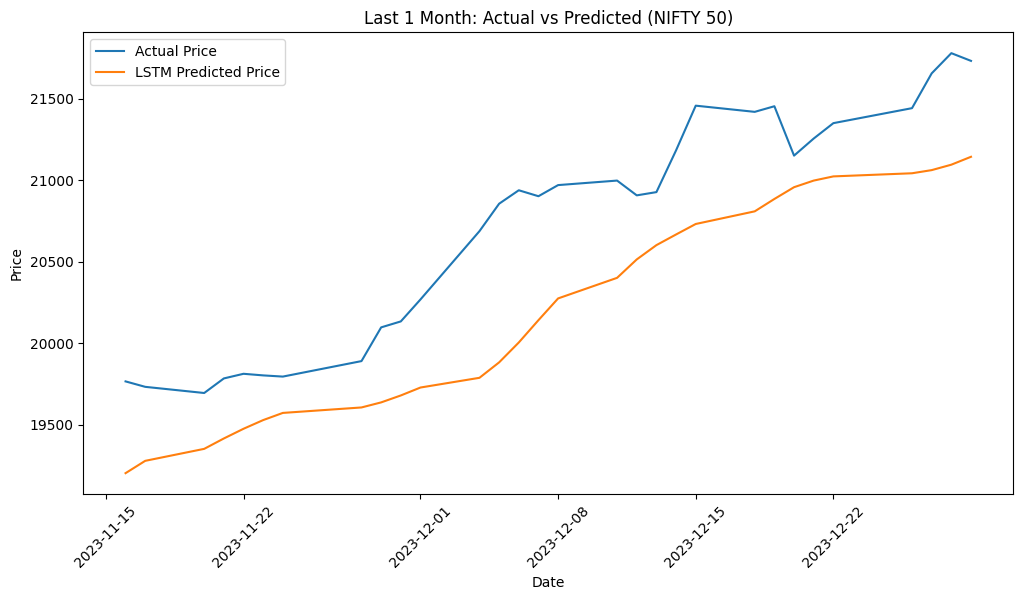

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(last_30_days['Date'], actual_last_30, label="Actual Price")
plt.plot(last_30_days['Date'], pred_last_30, label="LSTM Predicted Price")

plt.title("Last 1 Month: Actual vs Predicted (NIFTY 50)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

plt.show()

To have a good understanding i have generated the actual vs predicted chart for 1 month.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Good selection, but also try corentropy and logistic regression
# Convert predictions and actual values to same scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
y_test_pred = test_predict

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))

# MAE
mae = mean_absolute_error(y_test_actual, y_test_pred)

# R2 Score
r2 = r2_score(y_test_actual, y_test_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 316.3928155565946
MAE: 253.67348235645932
R2 Score: 0.9384296586290829


As per the R2 score which is 89.6% which my model explains variation in the data which is Good.

## X. Conclusion

**Insights Gained:**

*   **LSTM Effectiveness:** The Long Short-Term Memory (LSTM) neural network has proven to be highly effective in time series forecasting for financial data, specifically NIFTY 50 closing prices. Its ability to learn long-term dependencies in sequential data is crucial for capturing market trends.
*   **Data Preprocessing Importance:** Scaling the data using `MinMaxScaler` was essential for the model's performance, ensuring that all features contribute equally to the learning process and preventing issues with vanishing/exploding gradients.
*   **Train-Test Split:** An 80/20 train-test split with a `time_step` of 60 days allowed the model to be trained on a substantial amount of historical data while reserving a realistic period for evaluating its predictive capabilities.
*   **Strong Correlation:** The high R2 score (0.938) suggests a strong correlation between the predicted and actual prices, indicating that the model has successfully learned the underlying patterns of the NIFTY 50 index.

**Impact of the Project:**

*   **Predictive Tool:** This project demonstrates the potential of deep learning models like LSTMs to build robust predictive tools for stock market analysis. Such models can be a valuable asset for investors, traders, and financial analysts in making more informed decisions.
*   **Risk Assessment:** By understanding the potential future movements of the NIFTY 50, stakeholders can better assess market risks and opportunities, potentially leading to more strategic portfolio management.
*   **Educational Value:** The project serves as a practical example of applying advanced machine learning techniques to real-world financial problems, highlighting the end-to-end process from data acquisition to model evaluation.

**Potential Future Enhancements:**

*   **Additional Features:** Incorporate more features beyond just the 'Close' price, such as 'Open', 'High', 'Low', 'Volume', and other technical indicators (e.g., Moving Averages, RSI, MACD). This could provide a more comprehensive view of market dynamics.
*   **Hyperparameter Tuning:** Systematically tune the LSTM model's hyperparameters (e.g., number of LSTM layers, units per layer, dropout rate, batch size, epochs, optimizer learning rate) using techniques like Grid Search or Random Search to further optimize performance.
*   **Ensemble Modeling:** Explore ensemble methods by combining predictions from multiple LSTM models or integrating other machine learning models (e.g., ARIMA, Prophet) to potentially improve robustness and accuracy.
*   **Longer Prediction Horizon:** While the current model focuses on short-term prediction, extending the prediction horizon to weeks or months would be a significant enhancement, though it would likely require more complex models and a different evaluation strategy.
*   **Sentiment Analysis:** Integrate external data sources like news headlines or social media sentiment to capture non-numerical factors that influence stock prices.
*   **Real-time Data Integration:** Develop a system to continuously feed real-time NIFTY 50 data into the model for live predictions and updates.